<a href="https://colab.research.google.com/github/leticiatituana/EDA-Bank-Data/blob/main/Copia_Hiperpar%C3%A1metros_Random_Forest_LTitua%C3%B1a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo Hiperparámetros Random Forest
Coding Bootcamps ESPOL, Machine Learning and Predictions, Cohorte II

Instructor: Galo Castillo López

Estudiante: Leticia Tituaña


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv('./millas_por_galon.csv')

In [ ]:
df.head()

,nb_cilindros,desplazamiento,potencia,peso,aceleracion,anio,modeo,mpg
0,8,307.0,130.0,3504.0,12.0,70,"""chevrolet chevelle malibu""",18.0
1,8,350.0,165.0,3693.0,11.5,70,"""buick skylark 320""",15.0
2,8,318.0,150.0,3436.0,11.0,70,"""plymouth satellite""",18.0
3,8,304.0,150.0,3433.0,12.0,70,"""amc rebel sst""",16.0
4,8,302.0,140.0,3449.0,10.5,70,"""ford torino""",17.0


* nb_cilindros: la unidad de potencia del automóvil donde la gasolina se convierte en energía
* desplazamiento: desplazamiento del motor del auto
* potencia: tasa de rendimiento del motor en caballos de fuerza
* peso: el peso de un coche
* aceleracion: la aceleración del auto
* anio: anio en el que el auto fue lanzado al mercado
* origen: el origen del coche
* modelo: el nombre del auto
* mpg: Millaje/Millas por galón

In [ ]:
df.describe()

,nb_cilindros,desplazamiento,peso,aceleracion,anio,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,5140.000000,24.800000,82.000000,46.600000


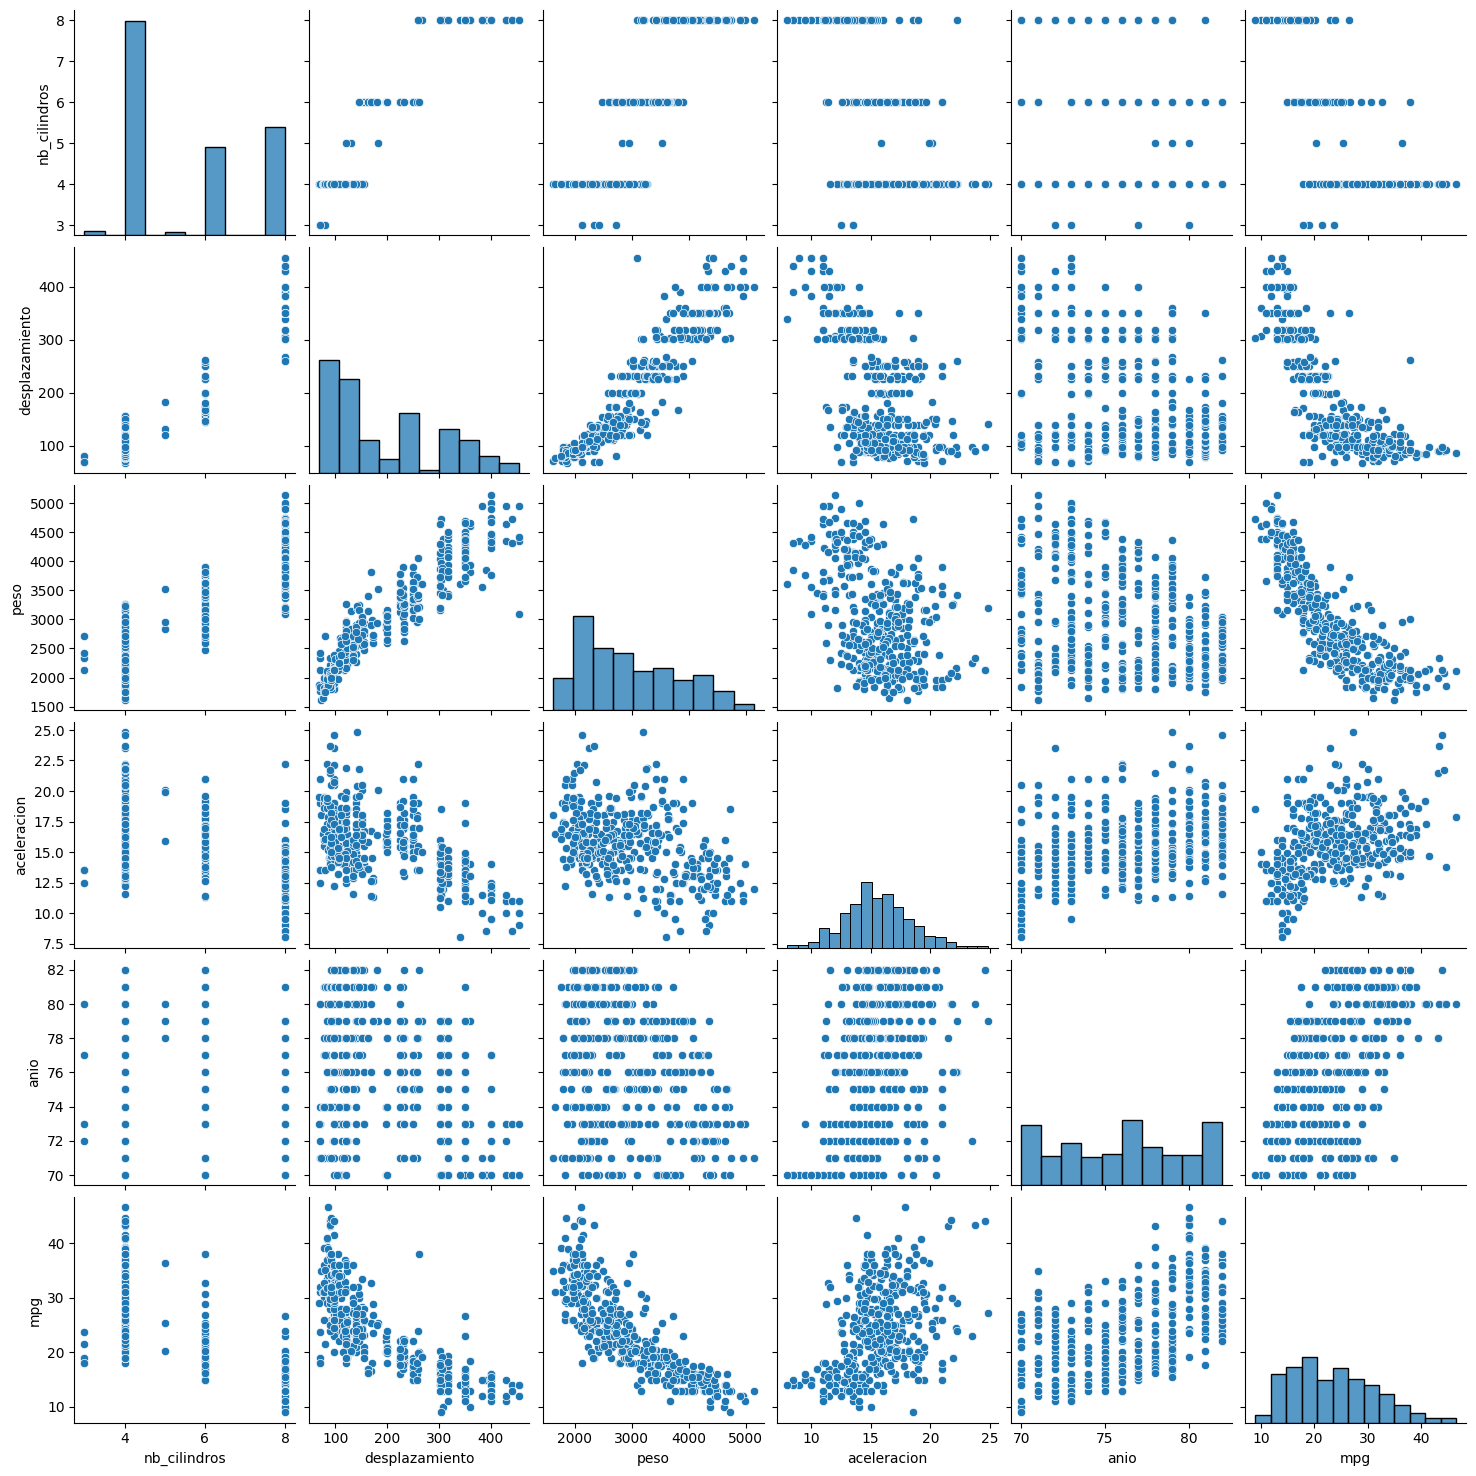

In [ ]:
sns.pairplot(df)

In [ ]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X = df[['desplazamiento',	'peso',	'aceleracion',	'anio']]

y = df['mpg']

X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_tmp, y_train_tmp, test_size=0.20, random_state=42)


In [ ]:
model_rl = LinearRegression()
model_rl.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_rl = model_rl.predict(X_val)
mae = mean_absolute_error(y_val, y_pred_rl)
mse = mean_squared_error(y_val, y_pred_rl)
r2 = r2_score(y_val, y_pred_rl)

# Resultados
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Absolute Error (MAE): 2.87
Mean Squared Error (MSE): 13.74
R^2 Score: 0.80


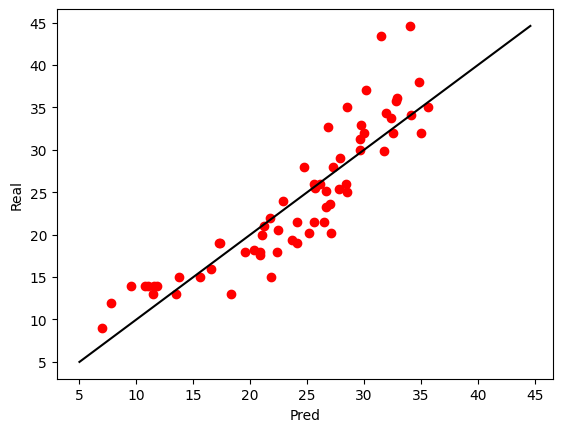

In [ ]:
plt.scatter(x=y_pred_rl, y=y_val, c='red', marker='o')
plt.plot([5, max(max(y_pred_rl), max(y_val))],
         [5, max(max(y_pred_rl), max(y_val))], 'k-')
plt.xlabel('Pred')
plt.ylabel('Real')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#RandomForestRegressor?

In [ ]:
model_rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                                 min_samples_split=2, max_features=0.9,
                                 random_state=0)
model_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features=0.9, n_estimators=200,
                      random_state=0)

In [ ]:
y_pred_rf = model_rf.predict(X_val)
mae = mean_absolute_error(y_val, y_pred_rf)
mse = mean_squared_error(y_val, y_pred_rf)
r2 = r2_score(y_val, y_pred_rf)

# Resultados
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Absolute Error (MAE): 2.13
Mean Squared Error (MSE): 8.78
R^2 Score: 0.87


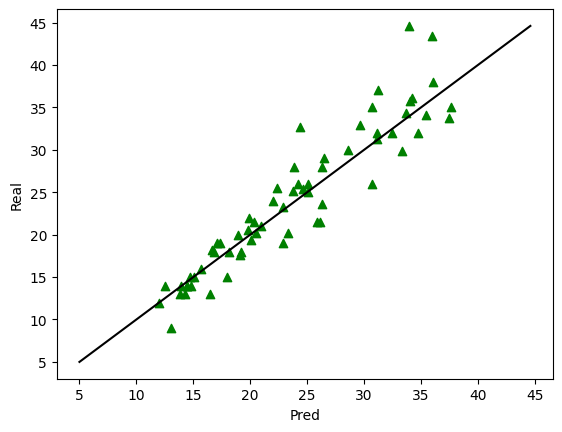

In [ ]:
plt.scatter(x=y_pred_rf, y=y_val, c='green', marker='^')
plt.plot([5, max(max(y_pred_rf), max(y_val))],
         [5, max(max(y_pred_rf), max(y_val))], 'k-')
plt.xlabel('Pred')
plt.ylabel('Real')
plt.show()

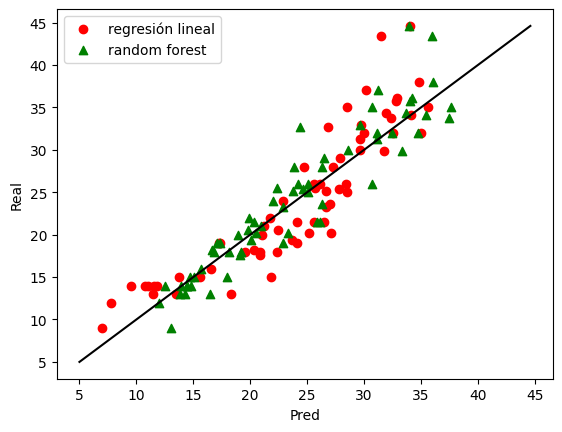

In [ ]:
plt.scatter(x=y_pred_rl, y=y_val, c='red', marker='o', label='regresión lineal')
plt.scatter(x=y_pred_rf, y=y_val, c='green', marker='^', label='random forest')
plt.plot([5, max(max(y_pred_rl), max(y_pred_rf), max(y_val))],
         [5, max(max(y_pred_rl), max(y_pred_rf), max(y_val))], 'k-')
plt.xlabel('Pred')
plt.ylabel('Real')
plt.legend()
plt.show()

**GridSearch**

In [ ]:
from sklearn.model_selection import GridSearchCV
model_rf_gs = RandomForestRegressor(random_state=0)

In [ ]:
param_grid = {'n_estimators': [600, 800, 1000], # 3
              'max_depth': list(range(6, 11)), # 5
              'min_samples_split': list(range(2, 5)), # 3
              'max_features': [0.90, 0.95, 1.0]} # 3

In [ ]:
gs = GridSearchCV(model_rf_gs, param_grid, cv=3, scoring='neg_mean_squared_error')
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [6, 7, 8, 9, 10],
                         'max_features': [0.9, 0.95, 1.0],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [600, 800, 1000]},
             scoring='neg_mean_squared_error')

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

In [ ]:
len(gs.cv_results_['params'])

135

In [ ]:
gs.cv_results_['params']

[{'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 2,
  'n_estimators': 600},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 2,
  'n_estimators': 800},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 2,
  'n_estimators': 1000},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 3,
  'n_estimators': 600},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 3,
  'n_estimators': 800},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 3,
  'n_estimators': 1000},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 4,
  'n_estimators': 600},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 4,
  'n_estimators': 800},
 {'max_depth': 6,
  'max_features': 0.9,
  'min_samples_split': 4,
  'n_estimators': 1000},
 {'max_depth': 6,
  'max_features': 0.95,
  'min_samples_split': 2,
  'n_estimators': 600},
 {'max_depth': 6,
  'max_features': 0.95,
  'min_samples_split': 2,
  'n_estimators': 

In [ ]:
gs.best_params_

{'max_depth': 9,
 'max_features': 0.9,
 'min_samples_split': 2,
 'n_estimators': 800}

In [ ]:
gs.cv_results_['mean_test_score']

array([-9.55993514, -9.48809627, -9.46968016, -9.58376284, -9.53965995,
       -9.50996653, -9.53747287, -9.50232995, -9.49808191, -9.55993514,
       -9.48809627, -9.46968016, -9.58376284, -9.53965995, -9.50996653,
       -9.53747287, -9.50232995, -9.49808191, -9.79814909, -9.78003003,
       -9.79226188, -9.82755573, -9.79826416, -9.79904577, -9.90847318,
       -9.88331814, -9.87653188, -9.32046018, -9.3150191 , -9.31312099,
       -9.43257775, -9.40467011, -9.40474109, -9.46715857, -9.42901206,
       -9.41276681, -9.32046018, -9.3150191 , -9.31312099, -9.43257775,
       -9.40467011, -9.40474109, -9.46715857, -9.42901206, -9.41276681,
       -9.67733761, -9.65982198, -9.66556627, -9.74408216, -9.73206155,
       -9.73797567, -9.78585659, -9.782355  , -9.78123761, -9.31888173,
       -9.27431472, -9.28768253, -9.41216538, -9.35926056, -9.34257121,
       -9.38145462, -9.3567658 , -9.37406674, -9.31888173, -9.27431472,
       -9.28768253, -9.41216538, -9.35926056, -9.34257121, -9.38

In [ ]:
print(gs.score(X_val, y_val))

-8.990084892911433


**RandomizedSearch**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, truncnorm, randint

In [ ]:
model_params = {
    # Muestreo aleatorio de enteros entre 600 y 1000 estimadores
    'n_estimators': randint(600, 1000),
    # Muestreo aleatorios de enteros entre profundidades máximas de 4 y 12
    'max_depth': randint(5, 12),
    # max_features con distribución normal, con media .85 y desviación estándar 0.1, acotado entre 0 y 1
    'max_features': truncnorm(a=0, b=1, loc=0.85, scale=0.1),
    # max_features con distribución uniforme entre 0.01 y 1.0 (0.01 + 0.999)
    # 'max_features': uniform(0.01, 0.999)
}

samples = 15  # number of random samples

In [ ]:
model_rf_rs = RandomForestRegressor(random_state=0)
rs = RandomizedSearchCV(model_rf_rs, param_distributions=model_params, n_iter=samples, cv=3,
                        scoring="neg_mean_squared_error")

In [ ]:
rs.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=0),
                   n_iter=15,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7906c3bea9d0>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7906c3be8690>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7906c3bd4e90>},
                   scoring='neg_mean_squared_error')

In [ ]:
print(rs.best_params_)

{'max_depth': 9, 'max_features': np.float64(0.854205530908423), 'n_estimators': 829}


In [ ]:
rs.cv_results_['mean_test_score']

array([-9.53108488, -9.29109035, -9.4914014 , -9.28139802, -9.22256189,
       -9.28510486, -9.24559411, -9.82016248, -9.2301972 , -9.31619772,
       -9.24053629, -9.55589834, -9.48833607, -9.49339722, -9.28019958])

In [ ]:
print(rs.score(X_val, y_val))

-8.997334611402863


### **######### Todo #########**
Utilice XGBoost para regresion (revise la clase `XGBRegressor` https://www.geeksforgeeks.org/xgboost-for-regression/) y `RandomizedSearchCV` con 5-fold cross-validation y 100 samples para optimizar 3 hiperparámetros que considere relevantes.

Responda: ¿El mejor modelo encontrado es mejor que los resultados obtenidos con Random Forest?

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
# Define features and target variable
X = df[['desplazamiento', 'peso', 'aceleracion', 'anio']]
y = df['mpg']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
# Define hyperparameter space for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# Initialize XGBRegressor and RandomizedSearchCV
xgb_model = XGBRegressor()
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10, #se redujo el número de iteraciones para que sea más rápido
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)

In [ ]:
# Fit the model
random_search.fit(X_train, y_train)

# Get the best parameters and evaluate the model
best_params = random_search.best_params_
y_pred_xgb = random_search.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

best_params, mse_xgb, r2_xgb

({'n_estimators': np.int64(100), 'max_depth': 5, 'learning_rate': 0.2},
 7.079901966280684,
 0.8683211781831733)

In [ ]:
# Define hyperparameter space for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# Initialize XGBRegressor and RandomizedSearchCV
xgb_model = XGBRegressor()
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=100, #se redujo el número de iteraciones para que sea más rápido
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)

In [ ]:
# Fit the model
random_search.fit(X_train, y_train)

# Get the best parameters and evaluate the model
best_params = random_search.best_params_
y_pred_xgb = random_search.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

best_params, mse_xgb, r2_xgb

({'n_estimators': np.int64(500), 'max_depth': 3, 'learning_rate': 0.01},
 5.069759405717669,
 0.9057077416298773)

# RESPUESTA

**Métrica	Random Forest**

*Mean Squared Error (MSE):* 8.78

*R^2 Score:* 0.87

**Métrica	XGBoost (con 100 iteraciones)**

*Mean Squared Error (MSE):* 5.07

*R^2 Score:* 0.90

El modelo de XGBoost supera claramente a Random Forest en precisión para este conjunto de datos. Sin embargo, Random Forest sigue siendo una opción viable para prototipado rápido o recursos limitados. XGBoost se recomienda cuando la precisión es crítica y se dispone de capacidad computacional suficiente.

**Bayesian Search**

Optuna es una librería que permite realizar búsquedas basadas en Estadística Bayesiana. https://optuna.org/#code_examples

In [ ]:
!pip install optuna

In [ ]:
import optuna

In [ ]:
def objective(trial):
    # Sugiere valores como hiperparámetros
    n_estimators = trial.suggest_int("n_estimators", 300, 800, log=True)
    max_depth = trial.suggest_int("max_depth", 6, 11)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 4)

    # Crea y ajusta un modelo
    model = RandomForestRegressor(
      n_estimators=n_estimators,
      max_depth=max_depth,
      min_samples_split=min_samples_split,
      random_state=0,
    )
    model.fit(X_train, y_train)

    # Predice y calcula el MSE
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)

    # Devuelve MSE
    return mse

In [ ]:
study = optuna.create_study(direction="minimize")

[I 2025-04-14 16:34:44,133] A new study created in memory with name: no-name-d07c0892-be03-421b-8af0-0268b9a527c2


In [ ]:
study.optimize(objective, n_trials=10, show_progress_bar=True)

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-14 16:34:49,975] Trial 0 finished with value: 1.2454549282759604 and parameters: {'n_estimators': 687, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 0 with value: 1.2454549282759604.
[I 2025-04-14 16:34:51,570] Trial 1 finished with value: 1.2464029388186604 and parameters: {'n_estimators': 678, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 0 with value: 1.2454549282759604.
[I 2025-04-14 16:34:52,148] Trial 2 finished with value: 1.7370360170299315 and parameters: {'n_estimators': 314, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 0 with value: 1.2454549282759604.
[I 2025-04-14 16:34:52,786] Trial 3 finished with value: 1.5380569931967072 and parameters: {'n_estimators': 346, 'max_depth': 8, 'min_samples_split': 2}. Best is trial 0 with value: 1.2454549282759604.
[I 2025-04-14 16:34:53,788] Trial 4 finished with value: 1.1769541322565593 and parameters: {'n_estimators': 510, 'max_depth': 11, 'min_samples_split': 2}. Best is trial 4 with value: 1.

In [ ]:
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

Best trial: FrozenTrial(number=4, state=1, values=[1.1769541322565593], datetime_start=datetime.datetime(2025, 4, 14, 16, 34, 52, 789729), datetime_complete=datetime.datetime(2025, 4, 14, 16, 34, 53, 788363), params={'n_estimators': 510, 'max_depth': 11, 'min_samples_split': 2}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=800, log=True, low=300, step=1), 'max_depth': IntDistribution(high=11, log=False, low=6, step=1), 'min_samples_split': IntDistribution(high=4, log=False, low=2, step=1)}, trial_id=4, value=None)
Best hyperparameters: {'n_estimators': 510, 'max_depth': 11, 'min_samples_split': 2}
